In [1]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy as np
import folium
import json
import matplotlib.pyplot as plt
from shapely.geometry import box
from rasterio.windows import from_bounds
from rasterio.plot import show
import random
from shapely.geometry import box
import osmnx as ox
import os
import os
import requests
import shutil
from PIL import Image, ImageFile
from geojson import Feature, FeatureCollection  # Add this import
import math
import torch
import transformers
import fiona
print("Fiona drivers GPKG available?", "GPKG" in fiona.supported_drivers)

Fiona drivers GPKG available? True


In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

CUDA available: True
NVIDIA A100 80GB PCIe


In [3]:
import os, sys, importlib
repo_root = "/users/project1/pt01183/Building-height-width"
if repo_root not in sys.path:
    sys.path.append(repo_root)

# Preferred: set env var and let config read it
os.environ["PROJECT_DIR"] = "/users/project1/pt01183/Building-height-width"


In [4]:
# 2) reload config, then segmentation, then process_data (in this order)
import modules.config as cfg
importlib.reload(cfg)

import modules.segmentation as seg
importlib.reload(seg)

import modules.process_data as pd
importlib.reload(pd)

import modules.road_network as rn

# 3) import the function fresh (so it uses the reloaded module)
from modules.process_data import download_images_for_points
from modules.road_network import get_road_network, select_points_on_road_network, attach_road_angle, remove_intersection_points

from modules.config import PROJECT_DIR
print("PROJECT_DIR =", PROJECT_DIR)

2025-12-29 16:10:20.965210: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-29 16:10:23.051155: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767021023.449077 1044279 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767021023.609190 1044279 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767021024.727607 1044279 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

PROJECT_DIR = /users/project1/pt01183/Building-height-width


## Post processing height csv

In [23]:
import pandas as pd
import geopandas as gpd

# paths
POINTS_GPKG = "/users/project1/pt01183/Building-height-width/Gdańsk, Poland/district_points.gpkg"
HEIGHTS_CSV = "/users/project1/pt01183/Building-height-width/heights.csv"

# load points
points = gpd.read_file(POINTS_GPKG, layer="points").to_crs(4326)
print("Points:", len(points))

# load heights
df = pd.read_csv(HEIGHTS_CSV)
print("Height rows:", len(df))

Points: 5340
Height rows: 19943


In [24]:
import os
import pandas as pd
import geopandas as gpd

POINTS_GPKG = "/users/project1/pt01183/Building-height-width/Gdańsk, Poland/district_points.gpkg"
HEIGHTS_CSV = "/users/project1/pt01183/Building-height-width/heights.csv"

# load data
points = gpd.read_file(POINTS_GPKG, layer="points").to_crs(4326)
df = pd.read_csv(HEIGHTS_CSV)

# normalize image column -> "9_left"
df["image_stem"] = (
    df["image"]
    .astype(str)
    .apply(lambda p: os.path.splitext(os.path.basename(p))[0])
)

# expected images (2 per point)
all_images = {
    f"{pid}_{side}"
    for pid in points["id"]
    for side in ("left", "right")
}

images_with_height = set(df["image_stem"].unique())
images_no_height   = all_images - images_with_height

print("Points:", len(points))
print("Expected images:", len(all_images))
print("Images with ≥1 height:", len(images_with_height))
print("Images without height:", len(images_no_height))
print("Coverage:", round(len(images_with_height) / len(all_images) * 100, 1), "%")



Points: 5340
Expected images: 10680
Images with ≥1 height: 6632
Images without height: 4053
Coverage: 62.1 %


In [25]:
per_image = (
    df.groupby("image_stem")
      .size()
      .rename("n_heights")
      .reset_index()
)

print(per_image["n_heights"].describe())

count    6632.000000
mean        3.007087
std         2.231263
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        38.000000
Name: n_heights, dtype: float64


In [26]:
print(df.columns)

Index(['image', 'group_idx', 'median_m', 'mean_m', 'count', 'image_stem'], dtype='object')


In [27]:
df["image_stem"].head(10)

0    2_190
1    2_190
2    2_190
3    2_190
4    2_190
5    2_190
6    2_190
7    2_190
8    6_196
9    6_196
Name: image_stem, dtype: object

In [28]:
df["image_stem"].isna().sum(), len(df)

(0, 19943)

In [29]:
import os
import pandas as pd

df = pd.read_csv("/users/project1/pt01183/Building-height-width/heights.csv")

df["image_stem"] = (
    df["image"]
    .astype(str)
    .apply(lambda p: os.path.splitext(os.path.basename(p))[0])
)


In [30]:
mask_old = ~df["image_stem"].str.endswith(("_left", "_right"))
mask_new = ~mask_old

print("Old test rows:", mask_old.sum())
print("New production rows:", mask_new.sum())

Old test rows: 40
New production rows: 19903


In [31]:
df = df[mask_new].copy()

In [32]:
df.head()

,image,group_idx,median_m,mean_m,count,image_stem
40,"/w/PROJ/Gdańsk, Poland/save_rgb/imgs/0_left.jpg",0,8.806692,9.978769,7,0_left
41,"/w/PROJ/Gdańsk, Poland/save_rgb/imgs/0_left.jpg",1,9.182802,9.182802,1,0_left
42,"/w/PROJ/Gdańsk, Poland/save_rgb/imgs/0_right.jpg",0,37.827586,34.926871,5,0_right
43,"/w/PROJ/Gdańsk, Poland/save_rgb/imgs/0_right.jpg",1,27.173835,27.173835,2,0_right
44,"/w/PROJ/Gdańsk, Poland/save_rgb/imgs/0_right.jpg",2,5.916588,5.916588,2,0_right


In [ ]:
df=df.to_csv("/users/project1/pt01183/Building-height-width/Gdańsk, Poland/height_csv_all.csv")

In [33]:
df = df.rename(columns={"count": "support_px"})

In [34]:
rep = (
    df.groupby("image_stem", as_index=False)
      .agg(
          height_m=("median_m", "min"),     # conservative height
          support=("support_px", "max"),    # strongest DBSCAN cluster
          n_groups=("median_m", "count")    # how many clusters found
      )
)

print(rep.shape)
rep.head()



(6627, 4)


,image_stem,height_m,support,n_groups
0,0_left,8.806692,7,4
1,0_right,2.282098,6,14
2,1000_left,19.887596,7,10
3,1000_right,17.833718,20,9
4,1001_left,13.406980,3,8


In [35]:
print(rep.describe())

           height_m      support     n_groups
count   6627.000000  6627.000000  6627.000000
mean      23.035665     6.704844     3.003320
std      327.735977     6.745186     2.225986
min        0.210675     1.000000     1.000000
25%        6.072051     2.000000     1.000000
50%       11.839509     4.000000     2.000000
75%       18.268445     9.000000     4.000000
max    24875.992281    42.000000    38.000000


In [36]:
rep_f = rep[
    (rep["height_m"] >= 2.5) &     # below camera height is meaningless
    (rep["height_m"] <= 120)       # ~40 floors upper bound
]


In [37]:
rep_f = rep_f[rep_f["support"] >= 3]

In [38]:
rep_strict = rep_f[
    (rep_f["support"] >= 5) &
    (rep_f["n_groups"] <= 6)
]


In [39]:
rep_f.describe()

,height_m,support,n_groups
count,3959.000000,3959.000000,3959.000000
mean,14.009673,9.869159,3.392271
std,9.570193,6.850608,2.252605
min,2.512040,3.000000,1.000000
25%,7.227738,5.000000,2.000000
50%,12.632739,8.000000,3.000000
75%,17.897528,13.000000,4.000000
max,103.590527,42.000000,20.000000


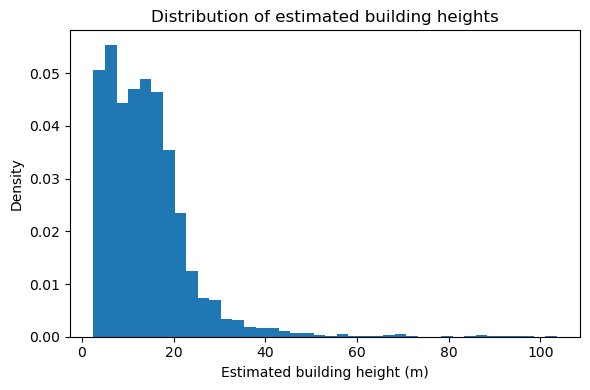

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(rep_f["height_m"], bins=40, density=True)
plt.xlabel("Estimated building height (m)")
plt.ylabel("Density")
plt.title("Distribution of estimated building heights")
plt.tight_layout()
plt.show()

## Overlay of images

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread

PLTOPTS = {"color": "#33FFFF", "s": 15, "edgecolors": "none", "zorder": 5}
colors_tables = ['blue','orange','green','red','purple',
                 'brown','pink','gray','olive','cyan']

def overlay_image(
    img_path,
    vref_path,
    out_path,
    heights_df=None
):
    img = imread(img_path)

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")

    ax_legends = []

    if os.path.exists(vref_path):
        d = np.load(vref_path)
        Vt = d["Vt_xy"]        # (N,2)
        Vb = d["Vb_xy"]        # (N,2)
        Hm = d["median_h_m"]   # (N,)

        for i in range(len(Vt)):
            color = colors_tables[i % len(colors_tables)]
            x = [Vt[i, 0], Vb[i, 0]]
            y = [Vt[i, 1], Vb[i, 1]]

            line_handle, = plt.plot(
                x, y,
                c=color,
                linewidth=2
            )
            plt.scatter(x, y, **PLTOPTS)

            # legend text from CSV (mean + median)
            if heights_df is not None:
                row = heights_df.iloc[i]
                label = (
                    f"average_height = {row['mean_m']:.4f}m, "
                    f"median_height = {row['median_m']:.4f}m"
                )
                line_handle.set_label(label)
                ax_legends.append(line_handle)

    if ax_legends:
        plt.legend(
            handles=ax_legends,
            loc="lower left",
            fontsize=8,
            framealpha=0.9
        )

    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(out_path, bbox_inches="tight", dpi=150)
    plt.close()



In [ ]:
from pathlib import Path
import pandas as pd

BASE = "/users/project1/pt01183/Building-height-width"
IMG_DIR  = f"{BASE}/Gdańsk, Poland/save_rgb/imgs"
VREF_DIR = f"{BASE}/Gdańsk, Poland/metrics"
OUT_DIR  = f"{BASE}/Gdańsk, Poland/overlay_check"

df = pd.read_csv(f"{BASE}/heights.csv")
df["image_stem"] = df["image"].apply(lambda x: Path(x).stem)

# choose 100 images with valid heights
sample_images = (
    df.groupby("image_stem")
      .filter(lambda g: len(g) > 0)
      .groupby("image_stem")
      .first()
      .sample(100, random_state=42)
      .index
)

for stem in sample_images:
    heights_img = (
        df[df["image_stem"] == stem]
        .sort_values("group_idx")
        .reset_index(drop=True)
    )

    overlay_image(
        img_path=f"{IMG_DIR}/{stem}.jpg",
        vref_path=f"{VREF_DIR}/{stem}_vertical_refs.npz",
        out_path=f"{OUT_DIR}/{stem}.png",
        heights_df=heights_img
    )
